In [9]:
import sympy as sp
from sympy.vector import curl

from neuralmag.common.engine import N, Variable, dV
from neuralmag.field_terms.field_term import FieldTerm

In [13]:
def component(a):
    match a:
        case N.x:
            return N.i
        case N.y:
            return N.j
        case N.z:
            return N.k
        case _:
            raise ValueError(f"{a} is not N.x, N.y, or N.z.")

In [14]:
m = N.z**2 * N.i - N.j + N.k

In [15]:
def Lifshitz_invariant(m, i, j, k):
    i_s = component(i)
    j_s = component(j)
    return m.dot(i_s) * m.dot(j_s).diff(k) - m.dot(j_s) * m.dot(i_s).diff(k)

In [16]:
Lifshitz_invariant(m, N.x, N.y, N.z)

2*N.z

In [17]:
def dmi_energy(D, m):
    # Directions in the coordinate system
    directions = [N.x, N.y, N.z]

    energy = 0
    for i in range(3):
        for j in range(3):
            for k in range(3):
                energy += D[i, j] * Lifshitz_invariant(
                    m, directions[i], directions[j], directions[k]
                )
    return 0.5 * energy

In [18]:
(3 + 1) % 3

1

In [19]:
def dmi_energy(D, m):
    # Directions in the coordinate system
    directions = [N.x, N.y, N.z]

    energy = 0
    for k in range(3):
        for i in range(3):
            energy += D[k, i] * Lifshitz_invariant(
                m, directions[(i + 1) % 3], directions[(i + 2) % 3], directions[k]
            )  # Check!
    return energy

In [20]:
Lifshitz_invariant(m_s, N.x, N.y, N.z)

NameError: name 'm_s' is not defined

In [92]:
Lifshitz_invariant(m_s, N.y, N.z, N.z)

m_y(N.x, N.y, N.z)*Derivative(m_z(N.x, N.y, N.z), N.z) - m_z(N.x, N.y, N.z)*Derivative(m_y(N.x, N.y, N.z), N.z)

In [93]:
Lifshitz_invariant(m_s, N.z, N.x, N.z)

-m_x(N.x, N.y, N.z)*Derivative(m_z(N.x, N.y, N.z), N.z) + m_z(N.x, N.y, N.z)*Derivative(m_x(N.x, N.y, N.z), N.z)

In [21]:
mx = sp.Function("m_x")(N.x, N.y, N.z)
my = sp.Function("m_y")(N.x, N.y, N.z)
mz = sp.Function("m_z")(N.x, N.y, N.z)
m_s = mx * N.i + my * N.j + mz * N.k

D = sp.MatrixSymbol("D", 3, 3)

In [82]:
D1 = sp.symbols("D_1")

In [83]:
D_mat = sp.Matrix([[D1, 0, 0], [0, D1, 0], [0, 0, D1]])
D_mat

Matrix([
[D_1,   0,   0],
[  0, D_1,   0],
[  0,   0, D_1]])

In [84]:
a1 = dmi_energy(D_mat, m_s).expand()
a1

D_1*m_x(N.x, N.y, N.z)*Derivative(m_y(N.x, N.y, N.z), N.z) - D_1*m_x(N.x, N.y, N.z)*Derivative(m_z(N.x, N.y, N.z), N.y) - D_1*m_y(N.x, N.y, N.z)*Derivative(m_x(N.x, N.y, N.z), N.z) + D_1*m_y(N.x, N.y, N.z)*Derivative(m_z(N.x, N.y, N.z), N.x) + D_1*m_z(N.x, N.y, N.z)*Derivative(m_x(N.x, N.y, N.z), N.y) - D_1*m_z(N.x, N.y, N.z)*Derivative(m_y(N.x, N.y, N.z), N.x)

In [85]:
a2 = (D1 * m_s.dot(curl(m_s))).expand()
a2

-D_1*m_x(N.x, N.y, N.z)*Derivative(m_y(N.x, N.y, N.z), N.z) + D_1*m_x(N.x, N.y, N.z)*Derivative(m_z(N.x, N.y, N.z), N.y) + D_1*m_y(N.x, N.y, N.z)*Derivative(m_x(N.x, N.y, N.z), N.z) - D_1*m_y(N.x, N.y, N.z)*Derivative(m_z(N.x, N.y, N.z), N.x) - D_1*m_z(N.x, N.y, N.z)*Derivative(m_x(N.x, N.y, N.z), N.y) + D_1*m_z(N.x, N.y, N.z)*Derivative(m_y(N.x, N.y, N.z), N.x)

In [86]:
(a1 + a2).expand().simplify()

0

In [101]:
LI = [[[N.y, N.z, N.x], [N.z, N.x, N.y]], [[N.x, N.y, N.z]]]
l_LI = len(LI)
print(l_LI)
ed = 0
for i in range(l_LI):
    D = sp.symbols(f"D{i}")
    l2 = len(LI[i])
    ed += D * sum(Lifshitz_invariant(m, *LI[i][j]) for j in range(l2))
ed

2


2*N.z*D1

In [1]:
from scipy import constants

import neuralmag as nm

# setup state
mesh = nm.Mesh((50, 50), (2e-9, 2e-9, 0.6e-9), (-50e-9, -50e-9, 0))
state = nm.State(mesh)

state.material.Ms = 1.0 / constants.mu_0
state.material.A = 1.6e-11
LI = [[["y", "z", "x"], ["z", "x", "y"]], [["x", "y", "z"]]]
state.material.D0 = 4e-3
state.material.D1 = -2 * 4e-3
state.material.D2 = 4e-3
state.material.Ku = 510e3
state.material.Ku_axis = [0, 0, 1]
state.material.alpha = 0.1

2024-12-18 16:08:26 NeuralMag:INFO [NeuralMag] Version 0.9.2
2024-12-18 16:08:26 NeuralMag:INFO [Mesh] 2D, 50 x 50 (size = 2e-09 x 2e-09 x 6e-10)
2024-12-18 16:08:27 NeuralMag:INFO [NeuralMag] Backend set to 'torch'.
2024-12-18 16:08:27 NeuralMag:INFO [NeuralMag] Set default device to 'cpu'.
2024-12-18 16:08:27 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2024-12-18 16:08:27 NeuralMag:INFO [State] Running on device: cpu (dtype = torch.float32, backend = torch)


In [2]:
# set circular geometry
x, y = state.coordinates()
state.rho = nm.CellFunction(
    state,
    tensor=nm.config.backend.np.where(x**2.0 + y**2.0 < 50e-9**2.0, 1.0, state.eps),
)

# initial magnetization
state.m = nm.VectorFunction(state).fill((0, 0, 1))

## register effective field
nm.ExchangeField().register(state, "exchange")
nm.DemagField().register(state, "demag")
nm.DMIField(LI).register(state, "dmi")
nm.UniaxialAnisotropyField().register(state, "aniso")
nm.TotalField("exchange", "demag", "dmi", "aniso").register(state)

# relax to skyrmion
llg = nm.LLGSolver(state)
llg.step(1e-9)
state.write_vti(["m", "rho"], "skyrmion.vti")

2024-12-18 16:08:27 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2024-12-18 16:08:27 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag')
2024-12-18 16:08:27 NeuralMag:INFO [DemagField]: Set up demag tensor


D₀⋅(\mathcal{L}_{yz}__{x} + \mathcal{L}_{zx}__{y}) + D₁⋅\mathcal{L}_{xy}__{z}

2024-12-18 16:08:27 NeuralMag:INFO [DMIField] Register state methods (field: 'h_dmi', energy: 'E_dmi')
2024-12-18 16:08:27 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso')
2024-12-18 16:08:27 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')
2024-12-18 16:08:27 NeuralMag:INFO [LLGSolverTorch] Initialize RHS function
2024-12-18 16:08:27 NeuralMag:INFO [LLGSolverTorch] Step: dt = 1e-09s, t = 0s


In [11]:
import sympy as sp

In [41]:
terms = []
for i, sublist in enumerate(LI):
    D_symbol = sp.symbols(f"D_{i}")
    temp = []
    for inner_list in sublist:
        i_comp, j_comp, k_comp = inner_list
        # Create symbolic representations for D_i and \mathcal{L}
        L_symbol = sp.Symbol(f"\\mathcal{{L}}_{{{i_comp},{j_comp}}}^{{{k_comp}}}")
        temp.append(L_symbol)
    terms.append(D_symbol * sp.Add(*temp))

# Combine all terms into a symbolic expression
expression = sp.Add(*terms)
sp.pprint(expression)

D₀⋅(\mathcal{L}_{y,z}__{x} + \mathcal{L}_{z,x}__{y}) + D₁⋅\mathcal{L}_{x,y}__{z}


In [42]:
expression

In [26]:
import sympy as sp

sp.init_printing()
a = sp.Symbol("A_0")
display(a)
print(a)

A_0


In [32]:
sp.pprint(a)

A₀


In [30]:
sp.srepr(a)

"Symbol('A_0')"

In [33]:
sp.pretty_print(a)

A₀


In [3]:
import matplotlib.pyplot as plt

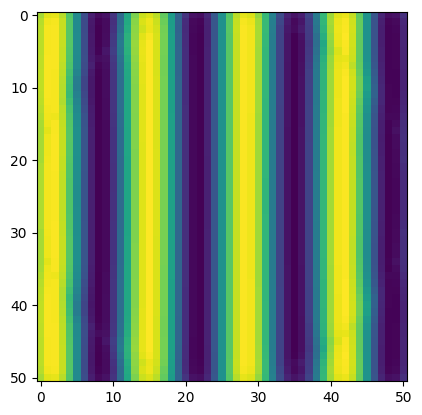

In [4]:
plt.imshow(state.m.tensor.numpy()[..., 2])

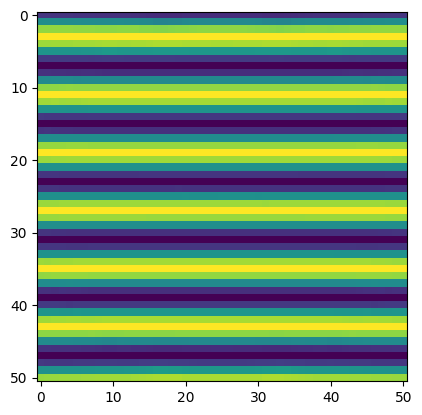

In [7]:
plt.imshow(state.m.tensor.numpy()[..., 1])